# The fake-news algorithm

In [1]:
import numpy as np
import numba as nb 
from consav.linear_interp import interp_1d_vec
import matplotlib.pyplot as plt
from consav.grids import equilogspace
from consav.markov import log_rouwenhorst

We continue from `04-Transition-Manually-GE-linear.ipynb`, using the same HANC model with an annual calibration.

## Setup from the previous notebooks

The household block, the steady state and the partial equilibrium impulse response, as written in `02-Transition-Manually-PE.ipynb`.

In [2]:
class Parameters:
    def __init__(self):
        # preferences
        self.beta = 0.9498866874132476
        self.sigma = 1.0
        
        # production
        self.alpha = 1/3
        self.delta = 0.1/3
        self.Gamma = 1.0
        
        # grids
        self.Na = 500
        self.a_min = 0.0
        self.a_max = 10_000.0 
        self.a_grid = equilogspace(self.a_min,self.a_max,self.Na)

        # income
        self.rho_z = 0.95
        self.sigma_psi = 0.30*(1.0-self.rho_z**2.0)**0.5
        self.Nz = 7
        self.z_grid, self.z_trans,self.z_ergodic,_,_ = log_rouwenhorst(self.rho_z,self.sigma_psi,self.Nz)
        

par = Parameters()

In [3]:
""" 
Household backward step
"""

def egm_ss(r, w, par, max_iter = 50_000, tol = 1e-12, verbose = False):
    """ solve the EGM for the steady state """

    # a. initialize
    y = w*par.z_grid
    c = r*par.a_grid[np.newaxis,:] + y[:,np.newaxis] 
    Va = (1+r)*c**(-par.sigma)

    # b. iterate
    for it in range(max_iter):

        # i. solve backwards
        c, a, Va_new = solve_hh_backwards_one_step(par.z_trans, par.z_grid, par.a_grid, par.sigma, par.beta, r, w, Va)

        # ii. check convergence
        error = np.max(np.abs(Va - Va_new))
        if verbose:
            print(error)
        if error < tol:
            return c, a, Va_new

        Va = Va_new
    
    

def solve_hh_backwards_one_step(z_trans, z_grid, a_grid, sigma, beta, r, w, vbeg_a):

    # vbeg_a is the derivative of the value function at the beginning of the period
    Nz, Na = vbeg_a.shape
    a = np.zeros((Nz, Na))
    c = np.zeros((Nz, Na)) 
    
    # a. solve step
    for i_z in range(Nz):
    
        ## i. get c(a',z)
        c_endo = (beta*vbeg_a[i_z])**(-1/sigma)
        
        # ii. compute m_endo = c(a',z) + a'
        m_endo = c_endo + a_grid # current consumption + end-of-period assets
        
        # iii. interpolation to fixed grid
        m = (1+r)*a_grid + w*z_grid[i_z] # exogenous grid of coh
        interp_1d_vec(m_endo,a_grid,m,a[i_z]) # fill up the array a[i_z]
        a[i_z,:] = np.fmax(a[i_z,:],0.0) # enforce borrowing constraint
        c[i_z] = m-a[i_z]

    # b. expectation step
    RHS = (1+r)*c**(-sigma)
    vbeg_a_new = z_trans @ RHS

    return c, a, vbeg_a_new


In [4]:
""" 
Household forward step
"""

def get_lottery(a, a_grid):
    # step 1: find the i such that a' lies between gridpoints a_i and a_(i+1)
    a_i = np.searchsorted(a_grid, a, side='right') - 1
    a_i = np.clip(a_i, 0, len(a_grid)-2)

    # step 2: implement (8) to obtain lottery probabilities pi
    a_pi = (a_grid[a_i+1] - a)/(a_grid[a_i+1] - a_grid[a_i])
    
    return a_i, a_pi

@nb.njit
def forward_policy(D, a_i, a_pi):
    Dend = np.zeros_like(D)
    for e in range(a_i.shape[0]):
        for a in range(a_i.shape[1]):
            # send pi(e,a) of the mass to gridpoint i(e,a)
            Dend[e, a_i[e,a]] += a_pi[e,a]*D[e,a]
            
            # send 1-pi(e,a) of the mass to gridpoint i(e,a)+1
            Dend[e, a_i[e,a]+1] += (1-a_pi[e,a])*D[e,a]
            
    return Dend

@nb.njit
def forward_iteration(D, z_trans, a_i, a_pi):
    Dend = forward_policy(D, a_i, a_pi)    
    return z_trans.T @ Dend

def distribution_ss(a, par, tol=1E-10):
    a_i, a_pi = get_lottery(a, par.a_grid)

    # as initial D, use stationary distribution for s, plus uniform over a
    D = par.z_ergodic[:, np.newaxis] * np.ones_like(par.a_grid) / len(par.a_grid)

    # now iterate until convergence to acceptable threshold
    for _ in range(100_000):
        D_new = forward_iteration(D, par.z_trans, a_i, a_pi)
        if np.max(np.abs(D_new - D)) < tol:
            return D_new
        D = D_new



In [5]:
""" 
Household block steady-state
"""

def household_ss(r, w, par, max_iter = 10_000, tol = 1e-8, verbose = False):
    c, a, Va = egm_ss(r, w, par, max_iter, tol, verbose) 
    D = distribution_ss(a, par)
    A = np.sum(D * a)
    C = np.sum(D * c) 
    return A, C, D, a, c, Va 

In [6]:
def find_ss_beta(beta, par):
    par.beta = beta
    r = 0.05
    w = 1-par.alpha
    K = 4 
    A, _, _, _, _, _  = household_ss(r, w, par) 
    print(A-K)
    return A-K

from scipy.optimize import brentq 
par.beta = brentq(find_ss_beta, 0.9, 0.952, args=(par,))

r_ss = 0.05 
Y_ss = 1 
K_ss = 4 
par.alpha = 1/3 
par.Gamma = Y_ss /(K_ss**par.alpha)
par.delta = par.alpha * par.Gamma * K_ss**(par.alpha-1) - r_ss
w_ss = (1-par.alpha) * Y_ss
A_ss, C_ss, D_init, a_ss, c_ss, Va_term = household_ss(r_ss, w_ss, par) 

-3.9999999999999987


18.85097130114365
-3.9999999999999964
-3.9754237154914476
-3.6903026999917037
-2.764996557364749
-0.8924888421929031
1.3487170555343209


-0.2148552940458055
0.009983083845268581
-0.00043326116878583676
-8.180241124478016e-07


2.2041035663278308e-11
-1.8816908031737967e-09


In [7]:
@nb.njit
def forward_iteration_trans(D_init, z_trans, a_i, a_pi, T):
    Nz, Na = D_init.shape
    D = np.zeros((T, Nz, Na))
    D[0] = D_init
    for t in range(T-1):
        D[t+1] = forward_iteration(D[t], z_trans, a_i[t], a_pi[t])
    return D

In [8]:
def get_impulse_response(Va_term, D_init, r_vec, w_vec, par):
    T = r_vec.size

    # backward step
    a_trans = np.zeros((T, par.Nz, par.Na))
    c_trans = np.zeros((T, par.Nz, par.Na))
    Va_trans = Va_term.copy()
    for t in reversed(range(T)):
        c_trans[t], a_trans[t], Va_trans = solve_hh_backwards_one_step(par.z_trans, 
                                                                       par.z_grid, 
                                                                       par.a_grid, 
                                                                       par.sigma, 
                                                                       par.beta, 
                                                                       r_vec[t], 
                                                                       w_vec[t], 
                                                                       Va_trans)

    # forward step
    a_i, a_pi = get_lottery(a_trans, par.a_grid)

    D_trans = forward_iteration_trans(D_init, par.z_trans, a_i, a_pi, T)    
    A_trans = np.sum(D_trans * a_trans, axis = (1,2))
    C_trans = np.sum(D_trans * c_trans, axis = (1,2))

    return C_trans, A_trans, D_trans, c_trans, a_trans

The brute-force Jacobian of savings with respect to $w$, as computed in `03-Transition-Manually-GE-nonlinear.ipynb`. We use it to check the fake-news Jacobian.

In [9]:
T = 300
r_vec = np.ones((T)) * r_ss
w_vec = np.ones((T)) * w_ss

_, A_no_shock, _, _, a_0 = get_impulse_response(Va_term, D_init, r_vec, w_vec, par)
a_ss = a_0[0] # to avoid numerical errors, run a blank transition and update steady state policy functions. This is for numerical precision only, not necessary per se.

In [10]:
h = 1e-4
J_w = np.zeros((T, T))

for s in range(T):
    r_vec = np.ones((T)) * r_ss
    w_vec = np.ones((T)) * w_ss
    
    w_vec[s] = w_ss + h

    C_trans, A_trans, _, _, _ = get_impulse_response(Va_term, D_init, r_vec, w_vec, par)
    J_w[:,s] = (A_trans - A_no_shock) / h

## The fake-news algorithm

We managed to speed up the time to compute a transition significantly, but computing the Jacobian is still costly. Luckily, we can do much faster using the fake-news algorithm of Auclert et al. (2021). 

Main insight: for every column $s$ of the Jacobian, all policy functions for $t>s$ are the steady state policy functions. 

Why? What matters is the distance to the shock! This means we can compute one transition for a shock at $s=T-1$, and back out the policy functions for every column $s$ by reordering them appropriately. 

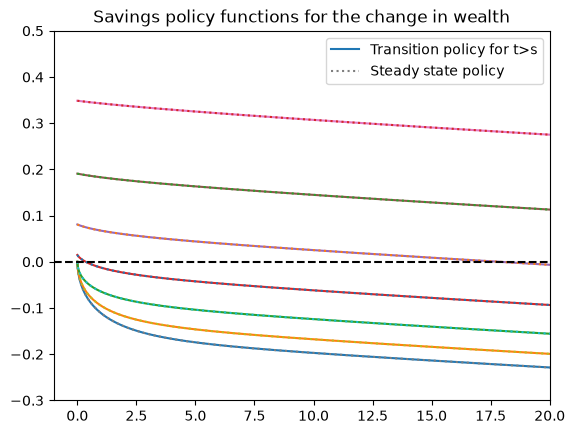

In [11]:
h = 0.01
r_vec = np.ones((T)) * r_ss
w_vec = np.ones((T)) * w_ss

s = 5
w_vec[s] = w_vec[s] + h

_, _, _, c_trans, a_trans = get_impulse_response(Va_term, D_init, r_vec, w_vec, par)

lines1 = plt.plot(par.a_grid, (a_trans[s+1]-par.a_grid[np.newaxis,:]).T)
lines2 = plt.plot(par.a_grid, (a_ss-par.a_grid[np.newaxis,:]).T, linestyle = ':')
plt.axhline(0, linestyle = '--', color = 'black')
lines1[0].set_label('Transition policy for t>s')
lines2[0].set_label('Steady state policy')
plt.xlim(-1, 20)
plt.ylim(-0.3, 0.5)
plt.legend()
plt.title("Savings policy functions for the change in wealth")
plt.show()

Another way to look at it is to see how policy function at a given point change during the transition (in % deviation from steady state policy).

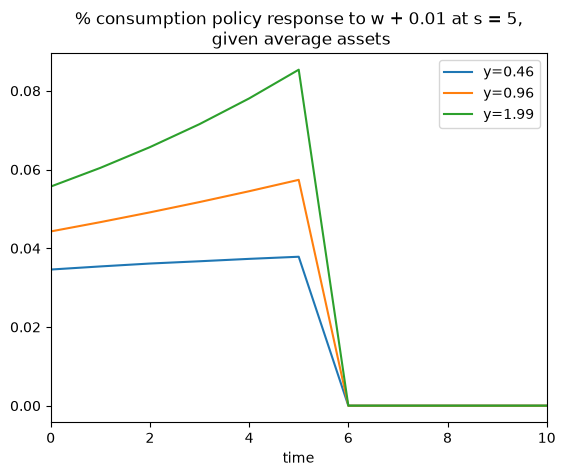

In [12]:
c_impulse = 100*(c_trans - c_ss) / c_ss # percent change in consumption policy function
i_ave = np.argmax(par.a_grid > K_ss) # first index of assets above average
for e in (0, 3, 6):
    plt.plot(c_impulse[:, e, i_ave], label=f"y={par.z_grid[e]:.2f}")
plt.xlim(0,10)
plt.xlabel('time')
plt.legend()
plt.title(f"% consumption policy response to w + {h} at s = {s},\n given average assets");

Using this intuition, we can do only one backward step, computing the impulse response to a shock at $s=T$, and then rearrange the policy functions in order to compute the Jacobian matrix. 

In practice, this means we only need one backward step, but still $T$ forward steps (the full Fake-News algorithm also has a way to avoid this, but we won't cover it today).

In [13]:
J_w_fake_news = np.zeros((T, T))

# First, compute the impulse response for a shock on w at the last period
r_vec = np.ones((T)) * r_ss
w_vec = np.ones((T)) * w_ss
w_vec[-1] = w_ss + h

_, _, _, _, a_trans_last = get_impulse_response(Va_term, D_init, r_vec, w_vec, par)

# Discretize the policies
a_i_last, a_pi_last = get_lottery(a_trans_last, par.a_grid)
a_i_ss,   a_pi_ss   = get_lottery(np.broadcast_to(a_ss,(T,)+a_ss.shape), par.a_grid)

# Rearrange them and do a forward path for each s 
for s in range(T):
    a_path = np.broadcast_to(a_ss,(T,)+a_ss.shape).copy()
    a_path[:s+1] = a_trans_last[T-1-s:]  # distance invariance

    ai = a_i_ss.copy()
    ap = a_pi_ss.copy()
    ai[:s+1] = a_i_last[T-1-s:]
    ap[:s+1] = a_pi_last[T-1-s:]

    D_trans = forward_iteration_trans(D_init, par.z_trans, ai, ap, T)
    A_trans = np.sum(D_trans * a_path, axis=(1,2))
    J_w_fake_news[:, s] = (A_trans - A_no_shock) / h

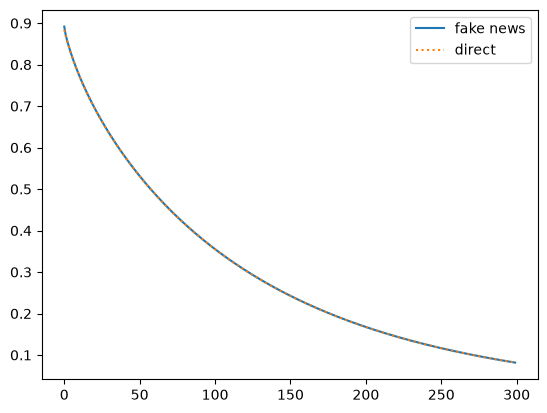

In [14]:
s = 0
plt.plot(J_w_fake_news[:,s], label = 'fake news')
plt.plot(J_w[:,s], linestyle = ':', label = 'direct')
plt.legend()
plt.show()

We can use the same code to compute the Jacobian with respect to $r$ using the fake-news algorithm again.

In [15]:
J_r_fake_news = np.zeros((T, T))

# First, compute the impulse response for a shock on r at the last period
r_vec = np.ones((T)) * r_ss
w_vec = np.ones((T)) * w_ss
r_vec[-1] = r_ss + h

_, _, _, _, a_trans_last = get_impulse_response(Va_term, D_init, r_vec, w_vec, par)

# Discretize the policies
a_i_last, a_pi_last = get_lottery(a_trans_last, par.a_grid)
a_i_ss,   a_pi_ss   = get_lottery(np.broadcast_to(a_ss,(T,)+a_ss.shape), par.a_grid)

# Rearrange them and do a forward path for each s 
for s in range(T):
    a_path = np.broadcast_to(a_ss,(T,)+a_ss.shape).copy()
    a_path[:s+1] = a_trans_last[T-1-s:]  # distance invariance

    ai = a_i_ss.copy()
    ap = a_pi_ss.copy()
    ai[:s+1] = a_i_last[T-1-s:]
    ap[:s+1] = a_pi_last[T-1-s:]

    D_trans = forward_iteration_trans(D_init, par.z_trans, ai, ap, T)
    A_trans = np.sum(D_trans * a_path, axis=(1,2))
    J_r_fake_news[:, s] = (A_trans - A_no_shock) / h